In [1]:
from pathlib import Path
import numpy as np
import jax.numpy as jnp
from jax import random
from sklearn.metrics import r2_score

from tensorflow_probability.substrates.jax import distributions as tfd
import optax

from sbijax import NPE
from sbijax.nn import make_maf

import matplotlib.pyplot as plt

AttributeError: module 'jax.interpreters.xla' has no attribute 'pytype_aval_mappings'

### Import and prepare data

In [2]:
data_dir = Path("./dt-data-time1/")
# n_batches = 10
n_batches = 1 # smaller test case

theta_indices = (3,4,5,6,7,8) # only positions

In [3]:
theta_list = []
for i in range(n_batches):
    file_path = data_dir / f"theta_batch_{i:02d}.npy"
    theta = np.load(file_path)
    theta_list.append(theta)

theta = jnp.concatenate(theta_list, axis=0)[:, theta_indices]

ERROR:2026-04-22 14:32:09,455:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/lugur3/miniconda3/envs/sbijax_env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/lugur3/miniconda3/envs/sbijax_env/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/lugur3/miniconda3/envs/sbijax_env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/h

In [4]:
x_list = []
for i in range(n_batches):
    file_path = data_dir / f"x_batch_{i:02d}.npy"
    x = np.load(file_path)       # shape: (N_batch, n_observables)
    x_list.append(x)

x = jnp.concatenate(x_list, axis=0)

mass_info = theta[:, :3]
x = jnp.concatenate([mass_info, x], axis=1)

In [5]:
# Split test set
test_ratio = 0.1
theta_test = theta[int((1.0-test_ratio)*theta.shape[0]):]
theta = theta[:int((1.0-test_ratio)*theta.shape[0])]
x_test = x[int((1.0-test_ratio)*x.shape[0]):]
x = x[:int((1.0-test_ratio)*x.shape[0])]

In [6]:
print("Theta shape: ", theta.shape)
print("x shape:     ", x.shape)

print("Theta test shape: ", theta_test.shape)
print("x test shape:     ", x_test.shape)

Theta shape:  (8999, 6)
x shape:      (8999, 15)
Theta test shape:  (1000, 6)
x test shape:      (1000, 15)


### Set prior distribution

In [7]:
n_dim_theta = theta.shape[1]
n_dim_x = x.shape[1]

# Set prior
def prior_fn():
    low  = jnp.array([0.1, 0.1, 0.1, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0])[np.array(theta_indices)]
    high =  jnp.array([10.0, 10.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0])[np.array(theta_indices)]
    prior = tfd.JointDistributionNamed(dict(
        theta=tfd.Independent(
            tfd.Uniform(low=low, high=high),
            reinterpreted_batch_ndims=1
        )
    ), batch_ndims=0)
    return prior

### Train NPE Model

In [8]:
# Define NPE model
neural_network = make_maf(n_dimension=n_dim_theta, n_layers=2)
fns = (prior_fn, None)
estim = NPE(fns, neural_network)

In [9]:
# Train model
data = {"theta": theta, "y": x}

params, info = estim.fit(
    random.PRNGKey(0),
    data=data,
    optimizer=optax.adam(1e-3),
    # n_early_stopping_patience=10,
    # n_early_stopping_delta=0.01,
)

print("Training finished.")

 15%|█▌        | 152/1000 [02:27<13:40,  1.03it/s]

Training finished.


### Test the trained model with a seen case

In [10]:
x_obs = x[0]
posterior_samples, _ = estim.sample_posterior(
    random.PRNGKey(1),
    params,
    observable=x_obs,
    n_samples=1000,
)

In [11]:
print("True positions:")
print(theta[0])
print("\n")
print("NPE Prediction:")
print(jnp.mean(posterior_samples.posterior["theta"].values[0], axis=0))

True positions:
[2.7710838 7.1797094 1.1384773 5.11331   4.658235  8.597766 ]


NPE Prediction:
[2.7758265 7.1771126 1.1357911 5.363031  4.567939  9.087262 ]


### Test the trained model with an unseen case

In [12]:
x_obs = x_test[0]
posterior_samples, _ = estim.sample_posterior(
    random.PRNGKey(1),
    params,
    observable=x_obs,
    n_samples=1000,
)

In [13]:
print("True positions:")
print(theta_test[0])
print("\n")
print("NPE Prediction:")
print(jnp.mean(posterior_samples.posterior["theta"].values[0], axis=0))

True positions:
[1.7698475 9.095422  1.0852685 2.739534  3.0319588 9.448404 ]


NPE Prediction:
[1.7708455 9.111402  1.0841825 2.805242  3.3468125 9.261282 ]


### Calculate R2 score across the datasets

In [14]:
posterior_means = []
posterior_stds = []

rng = np.random.default_rng(42)
eval_indices = rng.choice(len(x), size=100, replace=False)
for i in eval_indices:
    samples, _ = estim.sample_posterior(
        random.PRNGKey(i),
        params,
        observable=x[i],
        n_samples=1000,
    )
    theta_samples = samples.posterior["theta"].values.squeeze(0)
    posterior_means.append(theta_samples.mean(axis=0))
    posterior_stds.append(theta_samples.std(axis=0))

posterior_means = np.array(posterior_means)  # (n_test, 15)
posterior_stds = np.array(posterior_stds)  # (n_test, 15)

# R2 per dimension and overall
r2_per_dim = r2_score(theta[eval_indices], posterior_means, multioutput="raw_values")
r2_overall = r2_score(theta[eval_indices], posterior_means)

print("TRAINING SET:")
print("R² per theta dimension:")
for i, r in enumerate(r2_per_dim):
    print(f"  θ{i}: {r:.4f}")
print(f"\nOverall R²: {r2_overall:.4f}")

TRAINING SET:
R² per theta dimension:
  θ0: 0.9995
  θ1: 0.9990
  θ2: 0.9998
  θ3: 0.8183
  θ4: 0.7217
  θ5: 0.8047

Overall R²: 0.8905


In [15]:
posterior_means = []
posterior_stds = []

rng = np.random.default_rng(42)
eval_indices = rng.choice(len(x_test), size=100, replace=False)
for i in eval_indices:
    samples, _ = estim.sample_posterior(
        random.PRNGKey(i),
        params,
        observable=x_test[i],
        n_samples=1000,
    )
    theta_samples = samples.posterior["theta"].values.squeeze(0)
    posterior_means.append(theta_samples.mean(axis=0))
    posterior_stds.append(theta_samples.std(axis=0))

posterior_means = np.array(posterior_means)  # (n_test, 15)
posterior_stds = np.array(posterior_stds)  # (n_test, 15)

# R2 per dimension and overall
r2_per_dim = r2_score(theta_test[eval_indices], posterior_means, multioutput="raw_values")
r2_overall = r2_score(theta_test[eval_indices], posterior_means)

print("TEST SET:")
print("R² per theta dimension:")
for i, r in enumerate(r2_per_dim):
    print(f"  θ{i}: {r:.4f}")
print(f"\nOverall R²: {r2_overall:.4f}")

TEST SET:
R² per theta dimension:
  θ0: 0.9997
  θ1: 0.9998
  θ2: 0.9996
  θ3: 0.8973
  θ4: 0.7084
  θ5: 0.8036

Overall R²: 0.9014


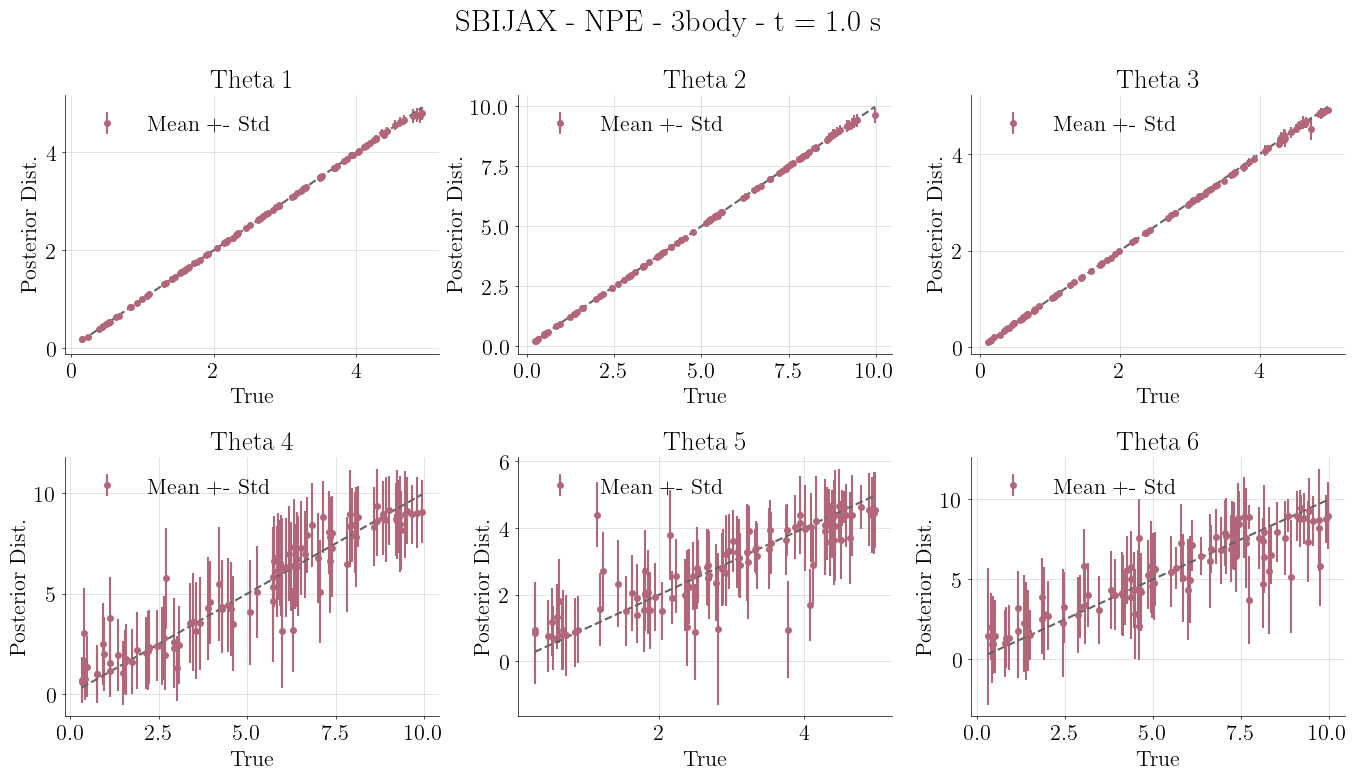

In [32]:
plt.rcParams.update({"font.size": 16})

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("SBIJAX - NPE - 3body - t = 1.0 s", fontsize=22)
axes = axes.flatten()

for i in range(2):
    for n in range(3):  # top and bottom row
        j = 3*i+n
        ax = axes[j]

        ax.errorbar(
            theta_test[eval_indices][:, j],
            posterior_means[:, j],
            yerr=1.64 * posterior_stds[:, j],  # ~90% CI
            fmt='o',
            markersize=4, label="Mean +- Std"
        )

        mn = min(theta_test[eval_indices][:,j].min(), posterior_means[:, j].min())
        mx = max(theta_test[eval_indices][:,j].max(), posterior_means[:, j].max())

        ax.plot([mn, mx], [mn, mx], '--')

        ax.set_title(f"Theta {j+1}")
        ax.set_xlabel("True")
        ax.set_ylabel("Posterior Dist.")
        ax.legend()

plt.tight_layout()
plt.show()